<a href="https://colab.research.google.com/github/HeshanNavindu-7/Trajectory-prediction/blob/main/05_lados_initialized_trajectory_dataset_creation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Step 1: Setup Drive, Folders, and Paths
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Main folders
# ------------------------------------------------------------
OIL_SPILL_ROOT = Path("/content/drive/MyDrive/Oil Spill")
TRAJECTORY_DIR = OIL_SPILL_ROOT / "04_Trajectory_LSTM"

DATA_DIR = TRAJECTORY_DIR / "data"
EXTRACTED_DIR = DATA_DIR / "extracted"
GENERATED_DIR = DATA_DIR / "generated"
SPLITS_DIR = DATA_DIR / "splits"
SEQUENCES_DIR = DATA_DIR / "sequences"

RESULT_DIR = TRAJECTORY_DIR / "results"
PLOT_DIR = TRAJECTORY_DIR / "plots"
LOG_DIR = TRAJECTORY_DIR / "logs"

for folder in [
    DATA_DIR,
    EXTRACTED_DIR,
    GENERATED_DIR,
    SPLITS_DIR,
    SEQUENCES_DIR,
    RESULT_DIR,
    PLOT_DIR,
    LOG_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Input and output files
# ------------------------------------------------------------
VALID_MASK_FEATURES_PATH = EXTRACTED_DIR / "trajectory_lados_valid_mask_features.csv"

INITIAL_STATES_PATH = GENERATED_DIR / "lados_initial_spill_states.csv"
TRAJECTORY_DATASET_PATH = GENERATED_DIR / "lados_initialized_physics_trajectory_dataset.csv"

CONFIG_PATH = RESULT_DIR / "trajectory_generation_config.json"
SUMMARY_PATH = RESULT_DIR / "trajectory_dataset_summary.csv"

print("Trajectory project:", TRAJECTORY_DIR)
print("Valid mask features path:", VALID_MASK_FEATURES_PATH)
print("Valid mask features exists:", VALID_MASK_FEATURES_PATH.exists())

Mounted at /content/drive
Trajectory project: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM
Valid mask features path: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/extracted/trajectory_lados_valid_mask_features.csv
Valid mask features exists: True


In [2]:
# ============================================================
# Step 2: Load Valid LADOS Mask Features
# ============================================================

valid_features_df = pd.read_csv(VALID_MASK_FEATURES_PATH)

print("Loaded valid mask features")
print("Shape:", valid_features_df.shape)
print("Columns:")
print(valid_features_df.columns.tolist())

valid_features_df.head()

Loaded valid mask features
Shape: (1795, 25)
Columns:
['sample_index', 'image_id', 'split', 'image_path', 'mask_path', 'mask_width', 'mask_height', 'area_pixels', 'area_ratio', 'centroid_x', 'centroid_y', 'centroid_x_norm', 'centroid_y_norm', 'bbox_x_min', 'bbox_y_min', 'bbox_x_max', 'bbox_y_max', 'bbox_width', 'bbox_height', 'bbox_area', 'bbox_area_ratio', 'is_empty_mask', 'is_tiny_mask', 'is_near_full_mask', 'is_valid_for_trajectory']


,sample_index,image_id,split,image_path,mask_path,mask_width,mask_height,area_pixels,area_ratio,centroid_x,...,bbox_x_max,bbox_y_max,bbox_width,bbox_height,bbox_area,bbox_area_ratio,is_empty_mask,is_tiny_mask,is_near_full_mask,is_valid_for_trajectory
0,0,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,310131,0.757156,294.021175,...,639.0,639.0,638,613,391094,0.954819,False,False,False,True
1,6,0DC66807-263B-4C21-9538-66512B084B40_jpeg_jpg....,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,249809,0.609885,308.721892,...,610.0,639.0,611,640,391040,0.954688,False,False,False,True
2,10,0_jpg.rf.8d5d7c6cb4efcc199a40711fd3d53c31,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,62818,0.153364,178.510236,...,415.0,320.0,416,321,133536,0.326016,False,False,False,True
3,11,0_jpg.rf.a14ad5fbc6f72bdf76dd34175f160f17,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,271416,0.662637,287.683464,...,639.0,639.0,639,640,408960,0.998437,False,False,False,True
4,12,0_jpg.rf.a393a1dc83c58060c71e9027d23efd7c,train,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,640,640,286559,0.699607,291.590999,...,639.0,639.0,640,640,409600,1.000000,False,False,False,True


In [3]:
# ============================================================
# Step 3: Validate Input Dataset
# ============================================================

required_columns = [
    "image_id",
    "split",
    "centroid_x",
    "centroid_y",
    "centroid_x_norm",
    "centroid_y_norm",
    "area_pixels",
    "area_ratio",
    "bbox_width",
    "bbox_height"
]

missing_cols = [col for col in required_columns if col not in valid_features_df.columns]

if len(missing_cols) > 0:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("All required columns exist.")

print("\nSplit counts:")
print(valid_features_df["split"].value_counts())

print("\nMissing values in required columns:")
print(valid_features_df[required_columns].isnull().sum())

print("\nArea range:")
print("Min area:", valid_features_df["area_pixels"].min())
print("Max area:", valid_features_df["area_pixels"].max())

print("\nCentroid norm ranges:")
print("centroid_x_norm:", valid_features_df["centroid_x_norm"].min(), "to", valid_features_df["centroid_x_norm"].max())
print("centroid_y_norm:", valid_features_df["centroid_y_norm"].min(), "to", valid_features_df["centroid_y_norm"].max())

All required columns exist.

Split counts:
split
train    1235
valid     370
test      190
Name: count, dtype: int64

Missing values in required columns:
image_id           0
split              0
centroid_x         0
centroid_y         0
centroid_x_norm    0
centroid_y_norm    0
area_pixels        0
area_ratio         0
bbox_width         0
bbox_height        0
dtype: int64

Area range:
Min area: 202
Max area: 388463

Centroid norm ranges:
centroid_x_norm: 0.0340769193120896 to 0.96353505100077
centroid_y_norm: 0.0077855603448275 to 0.9531721780132558


In [4]:
# ============================================================
# Step 4: Define Trajectory Simulation Configuration
# ============================================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Time settings
TIME_STEPS = 15
HOUR_SECONDS = 3600

# Local ocean scene coordinate system in meters
# LADOS pixel centroid is mapped into this local coordinate space.
SCENE_WIDTH_M = 2000
SCENE_HEIGHT_M = 2000

# Physics-guided drift coefficients
CURRENT_DRIFT_FACTOR = 1.00
WIND_DRIFT_FACTOR = 0.03

# Noise in meters for small turbulence/random movement
POSITION_NOISE_STD_M = 8.0

# Meteocean simulation ranges
WIND_STD = 3.0
WIND_CLIP = 8.0

CURRENT_STD = 0.08
CURRENT_CLIP = 0.25

WAVE_MIN = 0.2
WAVE_MAX = 3.5

# Area expansion
BASE_AREA_GROWTH_MIN = 0.001
BASE_AREA_GROWTH_MAX = 0.015

config = {
    "random_seed": RANDOM_SEED,
    "time_steps": TIME_STEPS,
    "hour_seconds": HOUR_SECONDS,
    "scene_width_m": SCENE_WIDTH_M,
    "scene_height_m": SCENE_HEIGHT_M,
    "current_drift_factor": CURRENT_DRIFT_FACTOR,
    "wind_drift_factor": WIND_DRIFT_FACTOR,
    "position_noise_std_m": POSITION_NOISE_STD_M,
    "wind_std": WIND_STD,
    "wind_clip": WIND_CLIP,
    "current_std": CURRENT_STD,
    "current_clip": CURRENT_CLIP,
    "wave_min": WAVE_MIN,
    "wave_max": WAVE_MAX,
    "metocean_source": "physics_guided_simulation"
}

with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=2)

print("Saved config:", CONFIG_PATH)
config

Saved config: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/trajectory_generation_config.json


{'random_seed': 42,
 'time_steps': 15,
 'hour_seconds': 3600,
 'scene_width_m': 2000,
 'scene_height_m': 2000,
 'current_drift_factor': 1.0,
 'wind_drift_factor': 0.03,
 'position_noise_std_m': 8.0,
 'wind_std': 3.0,
 'wind_clip': 8.0,
 'current_std': 0.08,
 'current_clip': 0.25,
 'wave_min': 0.2,
 'wave_max': 3.5,
 'metocean_source': 'physics_guided_simulation'}

In [5]:
# ============================================================
# Step 4: Define Trajectory Simulation Configuration
# ============================================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Time settings
TIME_STEPS = 15
HOUR_SECONDS = 3600

# Local ocean scene coordinate system in meters
# LADOS pixel centroid is mapped into this local coordinate space.
SCENE_WIDTH_M = 2000
SCENE_HEIGHT_M = 2000

# Physics-guided drift coefficients
CURRENT_DRIFT_FACTOR = 1.00
WIND_DRIFT_FACTOR = 0.03

# Noise in meters for small turbulence/random movement
POSITION_NOISE_STD_M = 8.0

# Meteocean simulation ranges
WIND_STD = 3.0
WIND_CLIP = 8.0

CURRENT_STD = 0.08
CURRENT_CLIP = 0.25

WAVE_MIN = 0.2
WAVE_MAX = 3.5

# Area expansion
BASE_AREA_GROWTH_MIN = 0.001
BASE_AREA_GROWTH_MAX = 0.015

config = {
    "random_seed": RANDOM_SEED,
    "time_steps": TIME_STEPS,
    "hour_seconds": HOUR_SECONDS,
    "scene_width_m": SCENE_WIDTH_M,
    "scene_height_m": SCENE_HEIGHT_M,
    "current_drift_factor": CURRENT_DRIFT_FACTOR,
    "wind_drift_factor": WIND_DRIFT_FACTOR,
    "position_noise_std_m": POSITION_NOISE_STD_M,
    "wind_std": WIND_STD,
    "wind_clip": WIND_CLIP,
    "current_std": CURRENT_STD,
    "current_clip": CURRENT_CLIP,
    "wave_min": WAVE_MIN,
    "wave_max": WAVE_MAX,
    "metocean_source": "physics_guided_simulation"
}

with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=2)

print("Saved config:", CONFIG_PATH)
config

Saved config: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/trajectory_generation_config.json


{'random_seed': 42,
 'time_steps': 15,
 'hour_seconds': 3600,
 'scene_width_m': 2000,
 'scene_height_m': 2000,
 'current_drift_factor': 1.0,
 'wind_drift_factor': 0.03,
 'position_noise_std_m': 8.0,
 'wind_std': 3.0,
 'wind_clip': 8.0,
 'current_std': 0.08,
 'current_clip': 0.25,
 'wave_min': 0.2,
 'wave_max': 3.5,
 'metocean_source': 'physics_guided_simulation'}

In [6]:
# ============================================================
# Step 5: Create Initial Spill States from LADOS Mask Features
# ============================================================

initial_states_df = valid_features_df.copy().reset_index(drop=True)

# Each valid mask becomes one simulated spill event
initial_states_df["spill_id"] = [
    f"SPILL_{i:05d}" for i in range(len(initial_states_df))
]

initial_states_df["source_image_id"] = initial_states_df["image_id"]
initial_states_df["source_split"] = initial_states_df["split"]

# Map normalized image centroid to local meter coordinates
initial_states_df["initial_x_m"] = initial_states_df["centroid_x_norm"] * SCENE_WIDTH_M
initial_states_df["initial_y_m"] = initial_states_df["centroid_y_norm"] * SCENE_HEIGHT_M

initial_states_df["initial_area_pixels"] = initial_states_df["area_pixels"]
initial_states_df["initial_area_ratio"] = initial_states_df["area_ratio"]

# Keep only useful columns
initial_state_columns = [
    "spill_id",
    "source_image_id",
    "source_split",
    "initial_x_m",
    "initial_y_m",
    "initial_area_pixels",
    "initial_area_ratio",
    "bbox_width",
    "bbox_height",
    "centroid_x",
    "centroid_y",
    "centroid_x_norm",
    "centroid_y_norm",
    "image_path",
    "mask_path"
]

initial_states_df = initial_states_df[initial_state_columns]

initial_states_df.to_csv(INITIAL_STATES_PATH, index=False)

print("Saved initial states:", INITIAL_STATES_PATH)
print("Initial spill states:", len(initial_states_df))
initial_states_df.head()

Saved initial states: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/generated/lados_initial_spill_states.csv
Initial spill states: 1795


,spill_id,source_image_id,source_split,initial_x_m,initial_y_m,initial_area_pixels,initial_area_ratio,bbox_width,bbox_height,centroid_x,centroid_y,centroid_x_norm,centroid_y_norm,image_path,mask_path
0,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,918.816172,1206.511402,310131,0.757156,638,613,294.021175,386.083649,0.459408,0.603256,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...
1,SPILL_00001,0DC66807-263B-4C21-9538-66512B084B40_jpeg_jpg....,train,964.755911,717.398943,249809,0.609885,611,640,308.721892,229.567662,0.482378,0.358699,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...
2,SPILL_00002,0_jpg.rf.8d5d7c6cb4efcc199a40711fd3d53c31,train,557.844487,450.698894,62818,0.153364,416,321,178.510236,144.223646,0.278922,0.225349,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...
3,SPILL_00003,0_jpg.rf.a14ad5fbc6f72bdf76dd34175f160f17,train,899.010824,1111.690657,271416,0.662637,639,640,287.683464,355.741010,0.449505,0.555845,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...
4,SPILL_00004,0_jpg.rf.a393a1dc83c58060c71e9027d23efd7c,train,911.221871,883.018004,286559,0.699607,640,640,291.590999,282.565761,0.455611,0.441509,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...


In [7]:
# ============================================================
# Step 6: Assign Slick Type Based on Area
# ============================================================

q1 = initial_states_df["initial_area_pixels"].quantile(0.33)
q2 = initial_states_df["initial_area_pixels"].quantile(0.66)

def assign_slick_type(area):
    if area <= q1:
        return "thin", 0
    elif area <= q2:
        return "medium", 1
    else:
        return "thick", 2

slick_types = initial_states_df["initial_area_pixels"].apply(assign_slick_type)

initial_states_df["slick_type"] = slick_types.apply(lambda x: x[0])
initial_states_df["slick_type_id"] = slick_types.apply(lambda x: x[1])

initial_states_df.to_csv(INITIAL_STATES_PATH, index=False)

print("Area quantile 33%:", q1)
print("Area quantile 66%:", q2)

print("\nSlick type counts:")
print(initial_states_df["slick_type"].value_counts())

initial_states_df.head()

Area quantile 33%: 70725.22
Area quantile 66%: 196341.12

Slick type counts:
slick_type
thick     610
thin      593
medium    592
Name: count, dtype: int64


,spill_id,source_image_id,source_split,initial_x_m,initial_y_m,initial_area_pixels,initial_area_ratio,bbox_width,bbox_height,centroid_x,centroid_y,centroid_x_norm,centroid_y_norm,image_path,mask_path,slick_type,slick_type_id
0,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,918.816172,1206.511402,310131,0.757156,638,613,294.021175,386.083649,0.459408,0.603256,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,thick,2
1,SPILL_00001,0DC66807-263B-4C21-9538-66512B084B40_jpeg_jpg....,train,964.755911,717.398943,249809,0.609885,611,640,308.721892,229.567662,0.482378,0.358699,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,thick,2
2,SPILL_00002,0_jpg.rf.8d5d7c6cb4efcc199a40711fd3d53c31,train,557.844487,450.698894,62818,0.153364,416,321,178.510236,144.223646,0.278922,0.225349,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,thin,0
3,SPILL_00003,0_jpg.rf.a14ad5fbc6f72bdf76dd34175f160f17,train,899.010824,1111.690657,271416,0.662637,639,640,287.683464,355.741010,0.449505,0.555845,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,thick,2
4,SPILL_00004,0_jpg.rf.a393a1dc83c58060c71e9027d23efd7c,train,911.221871,883.018004,286559,0.699607,640,640,291.590999,282.565761,0.455611,0.441509,/content/drive/MyDrive/Oil Spill/Best Detectio...,/content/drive/MyDrive/Oil Spill/Best Detectio...,thick,2


In [8]:
# ============================================================
# Step 7: Helper Functions for Physics-Guided Trajectory Simulation
# ============================================================

def clipped_normal(mean, std, clip_value):
    value = np.random.normal(mean, std)
    return float(np.clip(value, -clip_value, clip_value))


def update_autocorrelated_value(previous_value, new_value, persistence=0.85):
    return float((persistence * previous_value) + ((1.0 - persistence) * new_value))


def generate_initial_metocean_state():
    wind_u = clipped_normal(0.0, WIND_STD, WIND_CLIP)
    wind_v = clipped_normal(0.0, WIND_STD, WIND_CLIP)

    current_u = clipped_normal(0.0, CURRENT_STD, CURRENT_CLIP)
    current_v = clipped_normal(0.0, CURRENT_STD, CURRENT_CLIP)

    wave_height = float(np.random.uniform(WAVE_MIN, WAVE_MAX))

    return wind_u, wind_v, current_u, current_v, wave_height


def update_metocean_state(prev_wind_u, prev_wind_v, prev_current_u, prev_current_v, prev_wave_height):
    new_wind_u = clipped_normal(0.0, WIND_STD, WIND_CLIP)
    new_wind_v = clipped_normal(0.0, WIND_STD, WIND_CLIP)

    new_current_u = clipped_normal(0.0, CURRENT_STD, CURRENT_CLIP)
    new_current_v = clipped_normal(0.0, CURRENT_STD, CURRENT_CLIP)

    new_wave_height = float(np.random.uniform(WAVE_MIN, WAVE_MAX))

    wind_u = update_autocorrelated_value(prev_wind_u, new_wind_u, persistence=0.75)
    wind_v = update_autocorrelated_value(prev_wind_v, new_wind_v, persistence=0.75)

    current_u = update_autocorrelated_value(prev_current_u, new_current_u, persistence=0.90)
    current_v = update_autocorrelated_value(prev_current_v, new_current_v, persistence=0.90)

    wave_height = update_autocorrelated_value(prev_wave_height, new_wave_height, persistence=0.80)
    wave_height = float(np.clip(wave_height, WAVE_MIN, WAVE_MAX))

    return wind_u, wind_v, current_u, current_v, wave_height


def compute_spill_movement(wind_u, wind_v, current_u, current_v, wave_height):
    # Physics-guided drift
    drift_u = (CURRENT_DRIFT_FACTOR * current_u) + (WIND_DRIFT_FACTOR * wind_u)
    drift_v = (CURRENT_DRIFT_FACTOR * current_v) + (WIND_DRIFT_FACTOR * wind_v)

    # Wave increases spreading and uncertainty slightly
    wave_factor = 1.0 + (0.03 * wave_height)

    delta_x_m = drift_u * HOUR_SECONDS * wave_factor
    delta_y_m = drift_v * HOUR_SECONDS * wave_factor

    # Small random turbulence/noise
    delta_x_m += np.random.normal(0.0, POSITION_NOISE_STD_M)
    delta_y_m += np.random.normal(0.0, POSITION_NOISE_STD_M)

    return float(drift_u), float(drift_v), float(delta_x_m), float(delta_y_m)


def compute_area_growth(area_pixels, wave_height, slick_type_id):
    # Thicker slicks spread slightly slower; thin slicks spread slightly faster
    if slick_type_id == 0:
        slick_factor = 1.10
    elif slick_type_id == 1:
        slick_factor = 1.00
    else:
        slick_factor = 0.90

    base_growth = np.random.uniform(BASE_AREA_GROWTH_MIN, BASE_AREA_GROWTH_MAX)
    wave_growth_factor = 1.0 + (0.08 * wave_height)

    growth_rate = base_growth * wave_growth_factor * slick_factor

    new_area = area_pixels * (1.0 + growth_rate)
    new_area = min(new_area, SCENE_WIDTH_M * SCENE_HEIGHT_M)

    return float(new_area), float(growth_rate)

In [9]:
# ============================================================
# Step 8: Generate LADOS-Initialized Physics-Guided Trajectory Dataset
# ============================================================

trajectory_rows = []

for _, event in initial_states_df.iterrows():
    spill_id = event["spill_id"]
    source_image_id = event["source_image_id"]
    source_split = event["source_split"]

    x_m = float(event["initial_x_m"])
    y_m = float(event["initial_y_m"])
    area_pixels = float(event["initial_area_pixels"])
    area_ratio = float(event["initial_area_ratio"])

    bbox_width = float(event["bbox_width"])
    bbox_height = float(event["bbox_height"])

    slick_type = event["slick_type"]
    slick_type_id = int(event["slick_type_id"])

    # Initial metocean state
    wind_u, wind_v, current_u, current_v, wave_height = generate_initial_metocean_state()

    for t in range(TIME_STEPS):
        if t > 0:
            wind_u, wind_v, current_u, current_v, wave_height = update_metocean_state(
                wind_u,
                wind_v,
                current_u,
                current_v,
                wave_height
            )

        drift_u, drift_v, delta_x_m, delta_y_m = compute_spill_movement(
            wind_u,
            wind_v,
            current_u,
            current_v,
            wave_height
        )

        target_x_m = x_m + delta_x_m
        target_y_m = y_m + delta_y_m

        spatial_step_m = float(np.sqrt(delta_x_m**2 + delta_y_m**2))

        next_area_pixels, area_growth_rate = compute_area_growth(
            area_pixels,
            wave_height,
            slick_type_id
        )

        next_area_ratio = float(next_area_pixels / (640 * 640))

        trajectory_rows.append({
            "spill_id": spill_id,
            "source_image_id": source_image_id,
            "source_split": source_split,
            "time_hour": t,

            "x_m": x_m,
            "y_m": y_m,

            "area_pixels": area_pixels,
            "area_ratio": area_ratio,
            "bbox_width": bbox_width,
            "bbox_height": bbox_height,

            "slick_type": slick_type,
            "slick_type_id": slick_type_id,

            "wind_u": wind_u,
            "wind_v": wind_v,
            "current_u": current_u,
            "current_v": current_v,
            "wave_height": wave_height,

            "drift_u": drift_u,
            "drift_v": drift_v,

            "delta_x_m": delta_x_m,
            "delta_y_m": delta_y_m,
            "spatial_step_m": spatial_step_m,

            "target_x_m": target_x_m,
            "target_y_m": target_y_m,

            "next_area_pixels": next_area_pixels,
            "next_area_ratio": next_area_ratio,
            "area_growth_rate": area_growth_rate,

            "metocean_source": "physics_guided_simulation"
        })

        # Update state for next time step
        x_m = target_x_m
        y_m = target_y_m
        area_pixels = next_area_pixels
        area_ratio = next_area_ratio


trajectory_df = pd.DataFrame(trajectory_rows)

trajectory_df.to_csv(TRAJECTORY_DATASET_PATH, index=False)

print("Saved trajectory dataset:", TRAJECTORY_DATASET_PATH)
print("Trajectory dataset shape:", trajectory_df.shape)
print("Expected rows:", len(initial_states_df) * TIME_STEPS)

trajectory_df.head()

Saved trajectory dataset: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/generated/lados_initialized_physics_trajectory_dataset.csv
Trajectory dataset shape: (26925, 28)
Expected rows: 26925


,spill_id,source_image_id,source_split,time_hour,x_m,y_m,area_pixels,area_ratio,bbox_width,bbox_height,...,drift_v,delta_x_m,delta_y_m,spatial_step_m,target_x_m,target_y_m,next_area_pixels,next_area_ratio,area_growth_rate,metocean_source
0,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,0,918.816172,1206.511402,310131.000000,0.757156,638.0,613.0,...,0.109399,357.153796,410.365211,544.020625,1275.969968,1616.876613,313351.216624,0.765018,0.010383,physics_guided_simulation
1,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,1,1275.969968,1616.876613,313351.216624,0.765018,638.0,613.0,...,0.108807,222.091465,408.858460,465.284708,1498.061433,2025.735073,314876.163181,0.768741,0.004867,physics_guided_simulation
2,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,2,1498.061433,2025.735073,314876.163181,0.768741,638.0,613.0,...,0.093267,90.622609,350.527792,362.052745,1588.684042,2376.262865,317383.988734,0.774863,0.007964,physics_guided_simulation
3,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,3,1588.684042,2376.262865,317383.988734,0.774863,638.0,613.0,...,0.088058,4.812116,332.917627,332.952403,1593.496158,2709.180492,318107.612178,0.776630,0.002280,physics_guided_simulation
4,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,4,1593.496158,2709.180492,318107.612178,0.776630,638.0,613.0,...,0.111054,-34.392222,412.066296,413.499041,1559.103936,3121.246787,321229.058946,0.784251,0.009813,physics_guided_simulation


In [11]:
# ============================================================
# Step 9: Basic Dataset Checks
# ============================================================

print("Shape:", trajectory_df.shape)

print("\nUnique spill events:", trajectory_df["spill_id"].nunique())
print("Rows per event:")
print(trajectory_df.groupby("spill_id")["time_hour"].count().describe())

print("\nSource split counts by rows:")
print(trajectory_df["source_split"].value_counts())

print("\nSource split counts by events:")
print(trajectory_df.groupby("source_split")["spill_id"].nunique())

print("\nMissing values:")
print(trajectory_df.isnull().sum())

print("\nMetocean source:")
print(trajectory_df["metocean_source"].value_counts())

trajectory_df.describe()

Shape: (26925, 28)

Unique spill events: 1795
Rows per event:
count    1795.0
mean       15.0
std         0.0
min        15.0
25%        15.0
50%        15.0
75%        15.0
max        15.0
Name: time_hour, dtype: float64

Source split counts by rows:
source_split
train    18525
valid     5550
test      2850
Name: count, dtype: int64

Source split counts by events:
source_split
test      190
train    1235
valid     370
Name: spill_id, dtype: int64

Missing values:
spill_id            0
source_image_id     0
source_split        0
time_hour           0
x_m                 0
y_m                 0
area_pixels         0
area_ratio          0
bbox_width          0
bbox_height         0
slick_type          0
slick_type_id       0
wind_u              0
wind_v              0
current_u           0
current_v           0
wave_height         0
drift_u             0
drift_v             0
delta_x_m           0
delta_y_m           0
spatial_step_m      0
target_x_m          0
target_y_m          0
nex

,time_hour,x_m,y_m,area_pixels,area_ratio,bbox_width,bbox_height,slick_type_id,wind_u,wind_v,...,drift_u,drift_v,delta_x_m,delta_y_m,spatial_step_m,target_x_m,target_y_m,next_area_pixels,next_area_ratio,area_growth_rate
count,26925.000000,26925.000000,26925.000000,26925.000000,26925.000000,26925.000000,26925.000000,26925.000000,26925.000000,26925.000000,...,26925.000000,26925.000000,26925.000000,26925.000000,26925.000000,26925.000000,26925.000000,26925.000000,26925.000000,26925.000000
mean,7.000000,1062.941732,977.025737,150492.805539,0.367414,452.558774,457.134262,1.009471,0.040849,-0.022607,...,0.001606,-0.000712,6.059321,-2.637478,301.569664,1069.001053,974.388258,151789.419743,0.370580,0.009176
std,4.320574,2048.008160,2049.272565,115145.269649,0.281116,196.397567,199.238717,0.818615,1.564256,1.583493,...,0.066838,0.067201,254.065280,255.475316,197.263369,2187.570315,2188.717396,116078.491559,0.283395,0.004720
min,0.000000,-10122.432459,-8858.590018,202.000000,0.000493,14.000000,7.000000,0.000000,-8.000000,-8.000000,...,-0.349175,-0.389924,-1292.469419,-1437.945595,3.025038,-10542.942730,-8970.103308,204.997441,0.000500,0.000997
25%,3.000000,-13.789706,-142.750775,39634.990076,0.096765,310.000000,315.000000,0.000000,-0.895318,-0.934956,...,-0.037373,-0.039807,-142.165488,-151.514031,162.090680,-171.963600,-289.726215,39951.403780,0.097538,0.005149
50%,7.000000,1055.544727,994.252588,142737.094903,0.348479,515.000000,533.000000,1.000000,0.016269,-0.015329,...,0.001727,-0.000976,6.101778,-3.644660,258.592060,1082.050644,983.874995,143943.300439,0.351424,0.009100
75%,11.000000,2184.907640,2086.579948,240906.678841,0.588151,639.000000,637.000000,2.000000,0.955569,0.904126,...,0.041228,0.039249,156.876247,148.794018,392.846445,2327.949671,2245.014164,242926.578928,0.593082,0.013080
max,14.000000,10655.879331,10817.410010,443856.680542,1.083634,640.000000,640.000000,2.000000,8.000000,8.000000,...,0.403203,0.385819,1603.371452,1470.723230,1614.714691,10825.466007,11158.570762,448095.486764,1.093983,0.020490


In [12]:
# ============================================================
# Step 9B: Fix Area Ratio Range
# ============================================================

MAX_MASK_PIXELS = 640 * 640

trajectory_df["area_pixels"] = trajectory_df["area_pixels"].clip(lower=0, upper=MAX_MASK_PIXELS)
trajectory_df["next_area_pixels"] = trajectory_df["next_area_pixels"].clip(lower=0, upper=MAX_MASK_PIXELS)

trajectory_df["area_ratio"] = trajectory_df["area_pixels"] / MAX_MASK_PIXELS
trajectory_df["next_area_ratio"] = trajectory_df["next_area_pixels"] / MAX_MASK_PIXELS

# Re-save corrected dataset
trajectory_df.to_csv(TRAJECTORY_DATASET_PATH, index=False)

print("Corrected and saved:", TRAJECTORY_DATASET_PATH)
print("area_ratio min/max:", trajectory_df["area_ratio"].min(), trajectory_df["area_ratio"].max())
print("next_area_ratio min/max:", trajectory_df["next_area_ratio"].min(), trajectory_df["next_area_ratio"].max())

Corrected and saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/generated/lados_initialized_physics_trajectory_dataset.csv
area_ratio min/max: 0.0004931640625 1.0
next_area_ratio min/max: 0.0005004820335251687 1.0


In [13]:
# ============================================================
# Step 9C: Corrected Dataset Sanity Check
# ============================================================

check_values = {
    "rows": len(trajectory_df),
    "unique_spill_events": trajectory_df["spill_id"].nunique(),
    "min_area_ratio": trajectory_df["area_ratio"].min(),
    "max_area_ratio": trajectory_df["area_ratio"].max(),
    "min_next_area_ratio": trajectory_df["next_area_ratio"].min(),
    "max_next_area_ratio": trajectory_df["next_area_ratio"].max(),
    "mean_spatial_step_m": trajectory_df["spatial_step_m"].mean(),
    "max_spatial_step_m": trajectory_df["spatial_step_m"].max(),
    "missing_values": int(trajectory_df.isnull().sum().sum())
}

check_values

{'rows': 26925,
 'unique_spill_events': 1795,
 'min_area_ratio': 0.0004931640625,
 'max_area_ratio': 1.0,
 'min_next_area_ratio': 0.0005004820335251687,
 'max_next_area_ratio': 1.0,
 'mean_spatial_step_m': np.float64(301.5696642446111),
 'max_spatial_step_m': 1614.7146909271255,
 'missing_values': 0}

In [14]:
# ============================================================
# Step 10: Save Train / Valid / Test Spill ID Files
# ============================================================

train_spill_ids = sorted(
    trajectory_df[trajectory_df["source_split"] == "train"]["spill_id"].unique()
)

valid_spill_ids = sorted(
    trajectory_df[trajectory_df["source_split"] == "valid"]["spill_id"].unique()
)

test_spill_ids = sorted(
    trajectory_df[trajectory_df["source_split"] == "test"]["spill_id"].unique()
)

train_ids_df = pd.DataFrame({"spill_id": train_spill_ids})
valid_ids_df = pd.DataFrame({"spill_id": valid_spill_ids})
test_ids_df = pd.DataFrame({"spill_id": test_spill_ids})

train_ids_path = SPLITS_DIR / "train_spill_ids.csv"
valid_ids_path = SPLITS_DIR / "valid_spill_ids.csv"
test_ids_path = SPLITS_DIR / "test_spill_ids.csv"

train_ids_df.to_csv(train_ids_path, index=False)
valid_ids_df.to_csv(valid_ids_path, index=False)
test_ids_df.to_csv(test_ids_path, index=False)

print("Saved:", train_ids_path, "Events:", len(train_ids_df))
print("Saved:", valid_ids_path, "Events:", len(valid_ids_df))
print("Saved:", test_ids_path, "Events:", len(test_ids_df))

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/splits/train_spill_ids.csv Events: 1235
Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/splits/valid_spill_ids.csv Events: 370
Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/splits/test_spill_ids.csv Events: 190


In [15]:
# ============================================================
# Step 11: Save Trajectory Dataset Summary
# ============================================================

summary = {
    "total_spill_events": int(trajectory_df["spill_id"].nunique()),
    "total_rows": int(len(trajectory_df)),
    "time_steps_per_event": int(TIME_STEPS),

    "train_events": int(len(train_spill_ids)),
    "valid_events": int(len(valid_spill_ids)),
    "test_events": int(len(test_spill_ids)),

    "train_rows": int(len(trajectory_df[trajectory_df["source_split"] == "train"])),
    "valid_rows": int(len(trajectory_df[trajectory_df["source_split"] == "valid"])),
    "test_rows": int(len(trajectory_df[trajectory_df["source_split"] == "test"])),

    "min_area_ratio": float(trajectory_df["area_ratio"].min()),
    "max_area_ratio": float(trajectory_df["area_ratio"].max()),
    "min_next_area_ratio": float(trajectory_df["next_area_ratio"].min()),
    "max_next_area_ratio": float(trajectory_df["next_area_ratio"].max()),

    "mean_delta_x_m": float(trajectory_df["delta_x_m"].mean()),
    "mean_delta_y_m": float(trajectory_df["delta_y_m"].mean()),
    "mean_spatial_step_m": float(trajectory_df["spatial_step_m"].mean()),
    "median_spatial_step_m": float(trajectory_df["spatial_step_m"].median()),
    "max_spatial_step_m": float(trajectory_df["spatial_step_m"].max()),

    "mean_wind_speed": float(
        np.sqrt(trajectory_df["wind_u"]**2 + trajectory_df["wind_v"]**2).mean()
    ),
    "mean_current_speed": float(
        np.sqrt(trajectory_df["current_u"]**2 + trajectory_df["current_v"]**2).mean()
    ),
    "mean_wave_height": float(trajectory_df["wave_height"].mean()),

    "metocean_source": "physics_guided_simulation"
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(SUMMARY_PATH, index=False)

print("Saved summary:", SUMMARY_PATH)
summary_df

Saved summary: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/trajectory_dataset_summary.csv


,total_spill_events,total_rows,time_steps_per_event,train_events,valid_events,test_events,train_rows,valid_rows,test_rows,min_area_ratio,...,max_next_area_ratio,mean_delta_x_m,mean_delta_y_m,mean_spatial_step_m,median_spatial_step_m,max_spatial_step_m,mean_wind_speed,mean_current_speed,mean_wave_height,metocean_source
0,1795,26925,15,1235,370,190,18525,5550,2850,0.000493,...,1.0,6.059321,-2.637478,301.569664,258.59206,1614.714691,1.856068,0.056159,1.842152,physics_guided_simulation


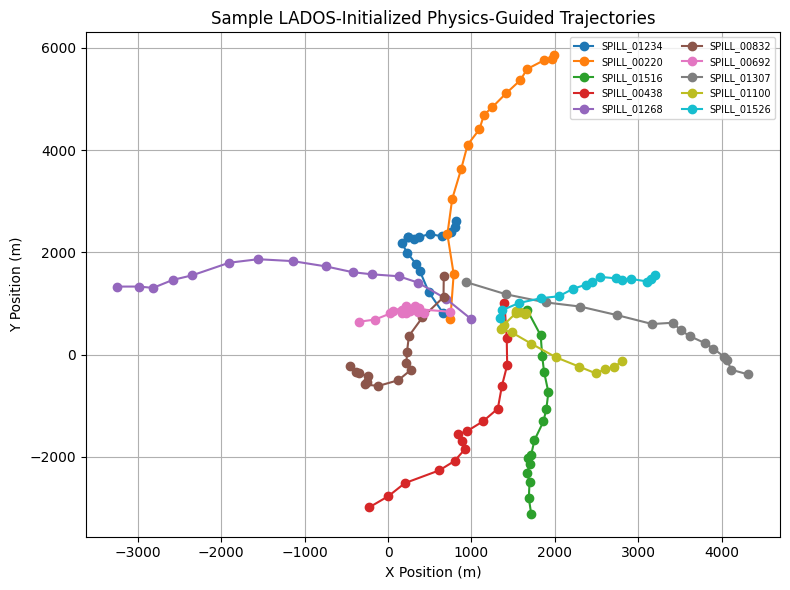

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/plots/sample_lados_initialized_trajectories.png


In [16]:
# ============================================================
# Step 12: Plot Sample LADOS-Initialized Trajectories
# ============================================================

sample_spill_ids = (
    trajectory_df["spill_id"]
    .drop_duplicates()
    .sample(n=min(10, trajectory_df["spill_id"].nunique()), random_state=42)
    .tolist()
)

plt.figure(figsize=(8, 6))

for spill_id in sample_spill_ids:
    event_df = trajectory_df[trajectory_df["spill_id"] == spill_id].sort_values("time_hour")

    plt.plot(
        event_df["x_m"],
        event_df["y_m"],
        marker="o",
        linewidth=1.5,
        label=spill_id
    )

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Sample LADOS-Initialized Physics-Guided Trajectories")
plt.grid(True)
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()

sample_traj_plot_path = PLOT_DIR / "sample_lados_initialized_trajectories.png"
plt.savefig(sample_traj_plot_path, dpi=200)
plt.show()

print("Saved:", sample_traj_plot_path)

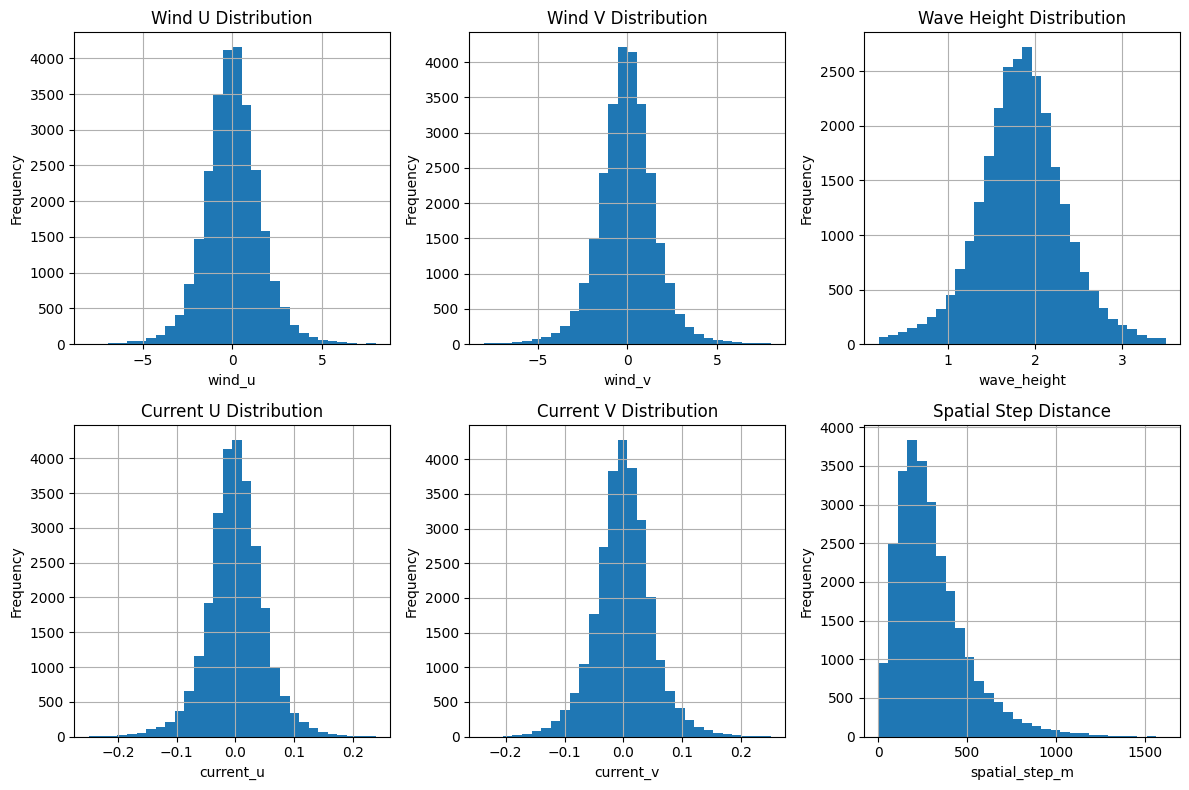

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/plots/metocean_variable_distributions.png


In [17]:
# ============================================================
# Step 13: Plot Meteocean Variable Distributions
# ============================================================

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.hist(trajectory_df["wind_u"], bins=30)
plt.title("Wind U Distribution")
plt.xlabel("wind_u")
plt.ylabel("Frequency")
plt.grid(True)

plt.subplot(2, 3, 2)
plt.hist(trajectory_df["wind_v"], bins=30)
plt.title("Wind V Distribution")
plt.xlabel("wind_v")
plt.ylabel("Frequency")
plt.grid(True)

plt.subplot(2, 3, 3)
plt.hist(trajectory_df["wave_height"], bins=30)
plt.title("Wave Height Distribution")
plt.xlabel("wave_height")
plt.ylabel("Frequency")
plt.grid(True)

plt.subplot(2, 3, 4)
plt.hist(trajectory_df["current_u"], bins=30)
plt.title("Current U Distribution")
plt.xlabel("current_u")
plt.ylabel("Frequency")
plt.grid(True)

plt.subplot(2, 3, 5)
plt.hist(trajectory_df["current_v"], bins=30)
plt.title("Current V Distribution")
plt.xlabel("current_v")
plt.ylabel("Frequency")
plt.grid(True)

plt.subplot(2, 3, 6)
plt.hist(trajectory_df["spatial_step_m"], bins=30)
plt.title("Spatial Step Distance")
plt.xlabel("spatial_step_m")
plt.ylabel("Frequency")
plt.grid(True)

plt.tight_layout()

metocean_plot_path = PLOT_DIR / "metocean_variable_distributions.png"
plt.savefig(metocean_plot_path, dpi=200)
plt.show()

print("Saved:", metocean_plot_path)

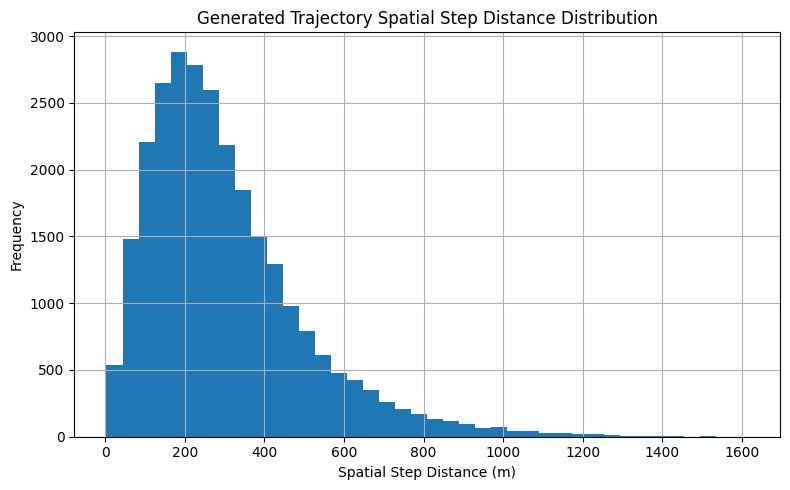

Saved: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/plots/spatial_step_distance_distribution.png


In [18]:
# ============================================================
# Step 14: Plot Spatial Step Distance Distribution
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(trajectory_df["spatial_step_m"], bins=40)
plt.xlabel("Spatial Step Distance (m)")
plt.ylabel("Frequency")
plt.title("Generated Trajectory Spatial Step Distance Distribution")
plt.grid(True)
plt.tight_layout()

spatial_step_plot_path = PLOT_DIR / "spatial_step_distance_distribution.png"
plt.savefig(spatial_step_plot_path, dpi=200)
plt.show()

print("Saved:", spatial_step_plot_path)

In [19]:
# ============================================================
# Step 15: Save Final Trajectory Dataset Creation Summary
# ============================================================

summary_md = f"""
# LADOS-Initialized Physics-Guided Trajectory Dataset Creation Summary

## Purpose
This notebook creates a physics-guided trajectory dataset for short-term oil spill movement prediction. The dataset is initialized using geometric oil-spill state features extracted from LADOS segmentation masks.

## Input File
`{VALID_MASK_FEATURES_PATH}`

## Output Files
- `{INITIAL_STATES_PATH}`
- `{TRAJECTORY_DATASET_PATH}`
- `{train_ids_path}`
- `{valid_ids_path}`
- `{test_ids_path}`
- `{SUMMARY_PATH}`

## Plot Files
- `{sample_traj_plot_path}`
- `{metocean_plot_path}`
- `{spatial_step_plot_path}`

## Dataset Summary
- Total spill events: {summary['total_spill_events']}
- Total trajectory rows: {summary['total_rows']}
- Time steps per event: {summary['time_steps_per_event']}
- Train events: {summary['train_events']}
- Validation events: {summary['valid_events']}
- Test events: {summary['test_events']}
- Mean spatial step distance: {summary['mean_spatial_step_m']:.4f} m
- Median spatial step distance: {summary['median_spatial_step_m']:.4f} m
- Maximum spatial step distance: {summary['max_spatial_step_m']:.4f} m
- Mean wind speed: {summary['mean_wind_speed']:.4f}
- Mean current speed: {summary['mean_current_speed']:.4f}
- Mean wave height: {summary['mean_wave_height']:.4f}

## Important Methodological Note
The LADOS dataset provides image-mask pairs for oil spill segmentation, but it does not provide synchronized temporal trajectory annotations, GPS timestamps, or real metocean measurements. Therefore, this dataset uses LADOS-derived spill geometry as the initial state and generates physics-guided simulated metocean variables for controlled LSTM trajectory model development.

## Coordinate System Note
The initial LADOS mask centroid is mapped into a local meter-based coordinate space. Subsequent trajectory positions are allowed to move beyond the initial image frame because oil spill drift may continue outside the original UAV image region.

## Meteocean Source
`physics_guided_simulation`

## Next Step
Use `{TRAJECTORY_DATASET_PATH}` in `06_lstm_trajectory_model_training.ipynb`.
"""

summary_md_path = RESULT_DIR / "TRAJECTORY_DATASET_CREATION_SUMMARY.md"
summary_md_path.write_text(summary_md)

print(summary_md)
print("Saved:", summary_md_path)


# LADOS-Initialized Physics-Guided Trajectory Dataset Creation Summary

## Purpose
This notebook creates a physics-guided trajectory dataset for short-term oil spill movement prediction. The dataset is initialized using geometric oil-spill state features extracted from LADOS segmentation masks.

## Input File
`/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/extracted/trajectory_lados_valid_mask_features.csv`

## Output Files
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/generated/lados_initial_spill_states.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/generated/lados_initialized_physics_trajectory_dataset.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/splits/train_spill_ids.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/splits/valid_spill_ids.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/splits/test_spill_ids.csv`
- `/content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/results/trajectory_da

In [20]:
# ============================================================
# Step 16: Final Output File Check
# ============================================================

required_files = [
    INITIAL_STATES_PATH,
    TRAJECTORY_DATASET_PATH,
    train_ids_path,
    valid_ids_path,
    test_ids_path,
    SUMMARY_PATH,
    RESULT_DIR / "TRAJECTORY_DATASET_CREATION_SUMMARY.md",
    sample_traj_plot_path,
    metocean_plot_path,
    spatial_step_plot_path
]

for file_path in required_files:
    print(file_path.name, "=>", file_path.exists())

lados_initial_spill_states.csv => True
lados_initialized_physics_trajectory_dataset.csv => True
train_spill_ids.csv => True
valid_spill_ids.csv => True
test_spill_ids.csv => True
trajectory_dataset_summary.csv => True
TRAJECTORY_DATASET_CREATION_SUMMARY.md => True
sample_lados_initialized_trajectories.png => True
metocean_variable_distributions.png => True
spatial_step_distance_distribution.png => True


In [21]:
# ============================================================
# Step 17: Final Quick Display
# ============================================================

print("Notebook 05 completed successfully.")
print("Trajectory dataset:", TRAJECTORY_DATASET_PATH)
print("Rows:", len(trajectory_df))
print("Events:", trajectory_df["spill_id"].nunique())
print("Time steps per event:", TIME_STEPS)
print("Metocean source:", trajectory_df["metocean_source"].unique())

trajectory_df.head()

Notebook 05 completed successfully.
Trajectory dataset: /content/drive/MyDrive/Oil Spill/04_Trajectory_LSTM/data/generated/lados_initialized_physics_trajectory_dataset.csv
Rows: 26925
Events: 1795
Time steps per event: 15
Metocean source: ['physics_guided_simulation']


,spill_id,source_image_id,source_split,time_hour,x_m,y_m,area_pixels,area_ratio,bbox_width,bbox_height,...,drift_v,delta_x_m,delta_y_m,spatial_step_m,target_x_m,target_y_m,next_area_pixels,next_area_ratio,area_growth_rate,metocean_source
0,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,0,918.816172,1206.511402,310131.000000,0.757156,638.0,613.0,...,-0.258126,218.710922,-1029.384851,1052.362884,1137.527094,177.126550,311869.622559,0.761400,0.005606,physics_guided_simulation
1,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,1,1137.527094,177.126550,311869.622559,0.761400,638.0,613.0,...,-0.208571,190.763100,-816.134848,838.132836,1328.290194,-639.008298,316875.892166,0.773623,0.016052,physics_guided_simulation
2,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,2,1328.290194,-639.008298,316875.892166,0.773623,638.0,613.0,...,-0.153581,285.132456,-601.709698,665.849141,1613.422650,-1240.717996,319716.419657,0.780558,0.008964,physics_guided_simulation
3,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,3,1613.422650,-1240.717996,319716.419657,0.780558,638.0,613.0,...,-0.090881,239.480147,-361.978562,434.026750,1852.902797,-1602.696557,321898.347679,0.785885,0.006825,physics_guided_simulation
4,SPILL_00000,01_taylor_jpeg_jpg.rf.4a466016aec4913557fe9fe8...,train,4,1852.902797,-1602.696557,321898.347679,0.785885,638.0,613.0,...,-0.093315,137.962307,-366.498055,391.604932,1990.865104,-1969.194612,325046.352886,0.793570,0.009780,physics_guided_simulation
